## Baseline 2: BCNN with Hard Pseudo Labels

## Setup

In [92]:
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
import pickle

In [44]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.25)

In [45]:
import medmnist
from medmnist import INFO, Evaluator

In [80]:
# Import local files
%load_ext autoreload
%autoreload 2
from bcnn_training import *
from cnn_training import get_semi_supervised_labels, SSLDataset
from plots import *
from variational_cnn import *
from constants import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [47]:
data_flag = 'dermamnist'
download = True

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(medmnist, info['python_class'])

In [48]:
# Note: this preprocesses data such that it has mean 0.5 and std dev 0.5.
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

# load the data
train_dataset = DataClass(split='train', transform=data_transform, download=download)
val_dataset = DataClass(split='val', transform=data_transform, download=download)
test_dataset = DataClass(split='test', transform=data_transform, download=download)

BATCH_SIZE = 128

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=2*BATCH_SIZE, shuffle=False)

In [49]:
def default_setup(lr=0.001, l2_weight=0.0, rho_init=-5.0):
    model = VariationalCNN(n_channels, n_classes, rho_init=rho_init)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=l2_weight)
    return model, criterion, optimizer

In [50]:
RANDOM_SEED = 42

## 50% Unlabeled Rate

#### First try some grid searching for learning rate and beta

In [87]:
# Create SSL versions of our datasets
unlabeled_rate = 0.5
train_labels_ssl_50 = get_semi_supervised_labels(train_dataset, unlabeled_rate=unlabeled_rate, seed=RANDOM_SEED)
train_ssl_dataset_50 = SSLDataset(train_dataset, train_labels_ssl_50)
train_ssl_loader_50 = data.DataLoader(train_ssl_dataset_50, batch_size=BATCH_SIZE, shuffle=True)

Unlabeled rate: 0.5 | Total examples: 7007 | Labeled examples: 3506 | Unlabeled examples: 3501
Class 0: 114/228 labeled, 114 unlabeled
Class 1: 180/359 labeled, 179 unlabeled
Class 2: 385/769 labeled, 384 unlabeled
Class 3: 40/80 labeled, 40 unlabeled
Class 4: 390/779 labeled, 389 unlabeled
Class 5: 2347/4693 labeled, 2346 unlabeled
Class 6: 50/99 labeled, 49 unlabeled


In [89]:
all_histories_50 = []
lrs = [0.01, 0.001, 0.0001]
betas = [0.1, 1.0, 10.0, 100.0]
for lr in lrs:
    for beta in betas:
        np.random.seed(RANDOM_SEED)  # reset after get_semi_supervised_labels
        torch.manual_seed(RANDOM_SEED)
        model, optimizer, criterion = default_setup(lr=lr, l2_weight=0.0, rho_init=-5.0)
        history = train_loop_bcnn_hard_pseudo_label(model, train_ssl_loader_50, val_loader, optimizer, criterion, num_epochs=20, alpha=0.5, beta=beta, num_samples=10, threshold=0.95)
        best_history = max(history, key=lambda x: x['val_auc_macro'])
        best_model = VariationalCNN(n_channels, n_classes)
        best_model.load_state_dict(best_history['model_state'])
        test_results = evaluate_bayesian(best_model, test_loader, device='cpu', mc_samples=20)

        all_histories_50.append({
            "lr": lr,
            "beta": beta,
            "history": history,
            "best_history": best_history,
            "test_results": test_results
        })

        print(f"Finished {len(all_histories_50)}/{len(lrs)*len(betas)}: lr={lr}, beta={beta} | Test AUC Macro: {test_results['macro_auc']:.4f} | Test NLL Macro: {test_results['macro_nll']:.4f}")

100%|██████████| 8/8 [00:01<00:00,  4.67it/s]


Epoch 1/20 | Train NLL: 1.0640 | Train KL (avg/batch): 0.2240 | Train Loss Unlabeled: 0.1890 | Unlabeled Examples Used: 642/3501 | Val NLL: 0.9224 | Val Macro NLL: 2.7831 | Val AUC Macro: 0.7895 | Val AUC Global: 0.9318


100%|██████████| 8/8 [00:01<00:00,  4.67it/s]


Epoch 2/20 | Train NLL: 0.9264 | Train KL (avg/batch): 0.2216 | Train Loss Unlabeled: 0.1353 | Unlabeled Examples Used: 1134/3501 | Val NLL: 0.8666 | Val Macro NLL: 2.3122 | Val AUC Macro: 0.8351 | Val AUC Global: 0.9367


100%|██████████| 8/8 [00:01<00:00,  4.66it/s]


...

Epoch 19/20 | Train NLL: 0.3585 | Train KL (avg/batch): 219.8995 | Train Loss Unlabeled: 0.0301 | Unlabeled Examples Used: 1339/3501 | Val NLL: 0.8172 | Val Macro NLL: 1.9489 | Val AUC Macro: 0.8893 | Val AUC Global: 0.9480


100%|██████████| 8/8 [00:01<00:00,  4.56it/s]


Epoch 20/20 | Train NLL: 0.3414 | Train KL (avg/batch): 219.6365 | Train Loss Unlabeled: 0.0322 | Unlabeled Examples Used: 1353/3501 | Val NLL: 0.8154 | Val Macro NLL: 2.0152 | Val AUC Macro: 0.8916 | Val AUC Global: 0.9488


100%|██████████| 8/8 [00:05<00:00,  1.49it/s]

preds: [5 1 2 ... 5 5 5]
Finished 12/12: lr=0.0001, beta=100.0 | Test AUC Macro: 0.8872 | Test NLL Macro: 1.9504


In [91]:
for h in all_histories_50:
    print(f"LR: {h['lr']} | Beta: {h['beta']} | Best Val AUC Macro: {h['best_history']['val_auc_macro']:.4f} | Val NLL Macro: {h['best_history']['val_macro_nll']:.4f} ")

LR: 0.01 | Beta: 0.1 | Best Val AUC Macro: 0.8774 | Val NLL Macro: 2.1713 
LR: 0.01 | Beta: 1.0 | Best Val AUC Macro: 0.8770 | Val NLL Macro: 1.9242 
LR: 0.01 | Beta: 10.0 | Best Val AUC Macro: 0.8729 | Val NLL Macro: 1.9832 
LR: 0.01 | Beta: 100.0 | Best Val AUC Macro: 0.8626 | Val NLL Macro: 2.2344 
LR: 0.001 | Beta: 0.1 | Best Val AUC Macro: 0.9052 | Val NLL Macro: 1.9737 
LR: 0.001 | Beta: 1.0 | Best Val AUC Macro: 0.9028 | Val NLL Macro: 1.8226 
LR: 0.001 | Beta: 10.0 | Best Val AUC Macro: 0.9036 | Val NLL Macro: 1.8063 
LR: 0.001 | Beta: 100.0 | Best Val AUC Macro: 0.9024 | Val NLL Macro: 1.8653 
LR: 0.0001 | Beta: 0.1 | Best Val AUC Macro: 0.8941 | Val NLL Macro: 1.9332 
LR: 0.0001 | Beta: 1.0 | Best Val AUC Macro: 0.8953 | Val NLL Macro: 1.9315 
LR: 0.0001 | Beta: 10.0 | Best Val AUC Macro: 0.8965 | Val NLL Macro: 1.9271 
LR: 0.0001 | Beta: 100.0 | Best Val AUC Macro: 0.8972 | Val NLL Macro: 1.9132 


In [93]:
with open('histories_50_finetuning.pkl', 'wb') as f:
    pickle.dump(all_histories_50, f)

#### Try different values of tau with Best LR=0.001, Beta=10.0 
(Seems like from above learning rate matters more than beta)

In [100]:
best = next(h for h in all_histories_50 if h['lr'] == 0.001 and h['beta'] == 10.0)

model, optimizer, criterion = default_setup(lr=best['lr'], l2_weight=0.0, rho_init=-5.0)
model.load_state_dict(best['best_history']['model_state'])

test_results = evaluate_bayesian(model, test_loader, device='cpu', mc_samples=20)
print(f"Best Model Test AUC Macro: {test_results['macro_auc']:.4f} | Test NLL Macro: {test_results['macro_nll']:.4f} | Test NLL Per Class: {test_results['per_class_nll']}")

100%|██████████| 8/8 [00:05<00:00,  1.58it/s]

preds: [5 5 2 ... 5 5 5]
Best Model Test AUC Macro: 0.8955 | Test NLL Macro: 1.8824 | Test NLL Per Class: [2.2083483  2.2457383  1.6465735  2.6874576  2.257582   0.16900016
 1.962117  ]


Trying different thresholds, with `lr=0.001, beta=10.0`

In [ ]:
tau_histories_50 = []
taus = [0.5, 0.7, 0.8, 0.9, 0.95]
for tau in taus:
    np.random.seed(RANDOM_SEED)
    torch.manual_seed(RANDOM_SEED)
    model, criterion, optimizer = default_setup(lr=0.001, l2_weight=0.0, rho_init=-5.0)
    history = train_loop_bcnn_hard_pseudo_label(model, train_ssl_loader_50, val_loader, criterion, optimizer, num_epochs=20, alpha=0.5, beta=10.0, num_samples=10, threshold=tau)
    tau_histories_50.append({
        "tau": tau,
        "history": history,
        "best_history": max(history, key=lambda x: x['val_auc_macro'])
    })
    print(f'Finished tau={tau}, {len(tau_histories_50)}/{len(taus)}')

100%|██████████| 8/8 [00:01<00:00,  4.58it/s]


Epoch 1/20 | Train NLL: 0.9522 | Train KL (avg/batch): 22.3933 | Train Loss Unlabeled: 0.2363 | Unlabeled Examples Used: 3049/3501 | Val NLL: 0.8489 | Val Macro NLL: 2.4390 | Val AUC Macro: 0.8564 | Val AUC Global: 0.9435


100%|██████████| 8/8 [00:01<00:00,  4.34it/s]


Epoch 2/20 | Train NLL: 0.8167 | Train KL (avg/batch): 22.1905 | Train Loss Unlabeled: 0.2029 | Unlabeled Examples Used: 3011/3501 | Val NLL: 0.7790 | Val Macro NLL: 1.7626 | Val AUC Macro: 0.8926 | Val AUC Global: 0.9494


100%|██████████| 8/8 [00:01<00:00,  4.74it/s]


...

Epoch 18/20 | Train NLL: 0.1086 | Train KL (avg/batch): 19.3429 | Train Loss Unlabeled: 0.0229 | Unlabeled Examples Used: 2224/3501 | Val NLL: 1.1558 | Val Macro NLL: 2.4360 | Val AUC Macro: 0.8549 | Val AUC Global: 0.9308


100%|██████████| 8/8 [00:01<00:00,  4.61it/s]


Epoch 19/20 | Train NLL: 0.1247 | Train KL (avg/batch): 19.1927 | Train Loss Unlabeled: 0.0289 | Unlabeled Examples Used: 2175/3501 | Val NLL: 1.1795 | Val Macro NLL: 2.6602 | Val AUC Macro: 0.8752 | Val AUC Global: 0.9324


100%|██████████| 8/8 [00:01<00:00,  4.99it/s]

Epoch 20/20 | Train NLL: 0.1335 | Train KL (avg/batch): 19.0453 | Train Loss Unlabeled: 0.0260 | Unlabeled Examples Used: 2227/3501 | Val NLL: 1.1213 | Val Macro NLL: 2.6291 | Val AUC Macro: 0.8770 | Val AUC Global: 0.9435
Finished tau=0.95, 5/5


In [110]:
with open('tau_histories_50.pkl', 'wb') as f:
    pickle.dump(tau_histories_50, f)

In [117]:
with open('tau_histories_50.pkl', 'rb') as f:
    tau_histories_50 = pickle.load(f)

for h in tau_histories_50:
    print(f"tau: {h['tau']} | Best Val AUC Macro: {h['best_history']['val_auc_macro']:.4f} | Val NLL Macro: {h['best_history']['val_macro_nll']:.4f} ")

tau: 0.5 | Best Val AUC Macro: 0.9047 | Val NLL Macro: 1.9588 
tau: 0.7 | Best Val AUC Macro: 0.9062 | Val NLL Macro: 1.9003 
tau: 0.8 | Best Val AUC Macro: 0.9007 | Val NLL Macro: 1.9083 
tau: 0.9 | Best Val AUC Macro: 0.9093 | Val NLL Macro: 1.7762 
tau: 0.95 | Best Val AUC Macro: 0.9036 | Val NLL Macro: 1.8063 


#### Evaluate the best: tau=0.9, lr=0.001, beta=10.0

In [132]:
best = next(h for h in tau_histories_50 if h['tau'] == 0.9)
best_bcnn_history_50 = best['history']
best_bcnn_50, criterion, optimizer = default_setup(lr=0.001, l2_weight=0.0, rho_init=-5.0)
best_bcnn_50.load_state_dict(best['best_history']['model_state'])

<All keys matched successfully>

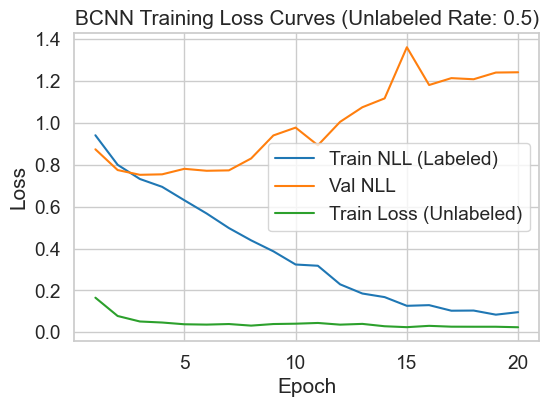

In [133]:
plot_loss_curves_bcnn(best_bcnn_history_50, unlabeled_rate=unlabeled_rate, use_unlabeled=True)

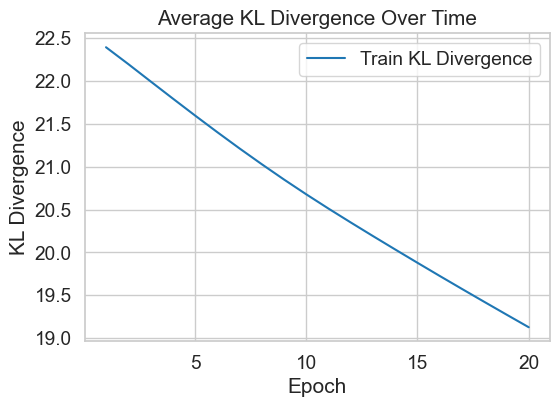

In [134]:
plot_kl(best_bcnn_history_50)

In [135]:
test_results_bcnn_50 = evaluate_bayesian(best_bcnn_50, test_loader, device='cpu')

100%|██████████| 8/8 [00:04<00:00,  1.63it/s]

preds: [5 2 2 ... 5 5 5]


In [136]:
print(f"Test AUC Macro: {test_results_bcnn_50['macro_auc']:.4f} | Test AUC Global: {test_results_bcnn_50['global_auc']:.4f}")
print(f"Test Macro NLL: {test_results_bcnn_50['macro_nll']:.4f} | Test Per-Class NLL: {test_results_bcnn_50['per_class_nll']}")

Test AUC Macro: 0.8988 | Test AUC Global: 0.9536
Test Macro NLL: 1.9227 | Test Per-Class NLL: [2.1271377  2.7323937  1.7795302  3.51119    1.1471651  0.25507358
 1.9063197 ]


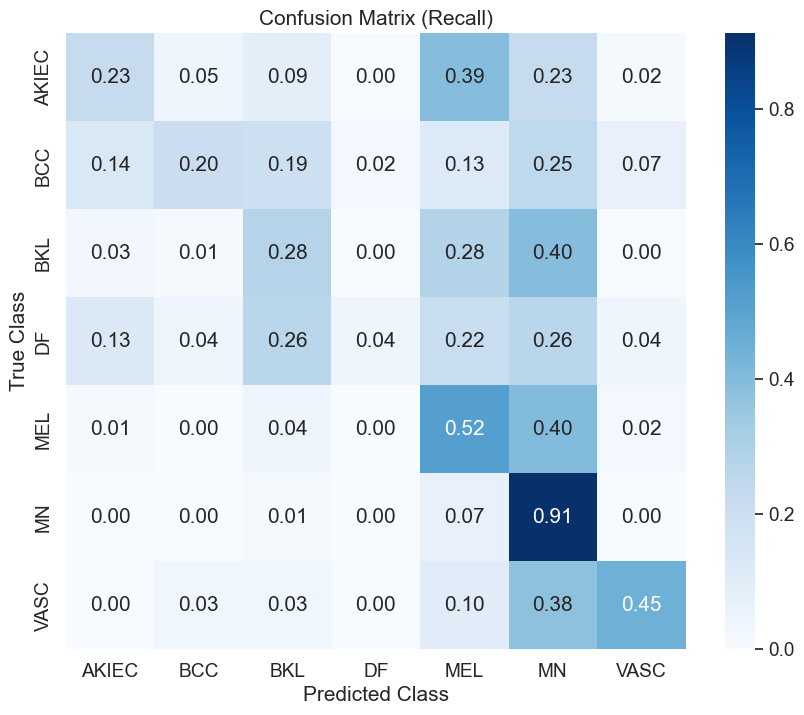

In [137]:
plot_per_class_recall(test_results_bcnn_50['confusion_matrix'], list(short_labels.values()))

## 75% Unlabeled Rate

## 90% Unlabeled Rate